<a href="https://colab.research.google.com/github/Ganika-R/24ADI003-EXP3/blob/main/Single_Layer_Perceptron_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single Layer Perceptron
Implements Task 1 (AND/OR) and Task 2 (Random Dataset).

AND Accuracy: 1.0
Pred: [0 0 0 1]


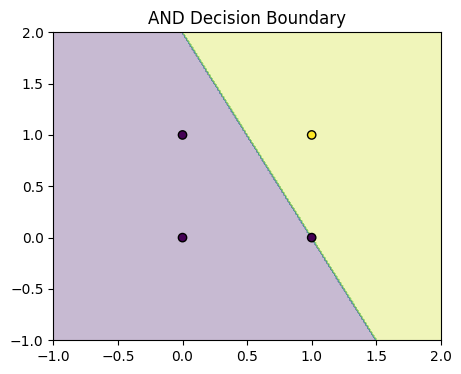

OR Accuracy: 1.0
Pred: [0 1 1 1]


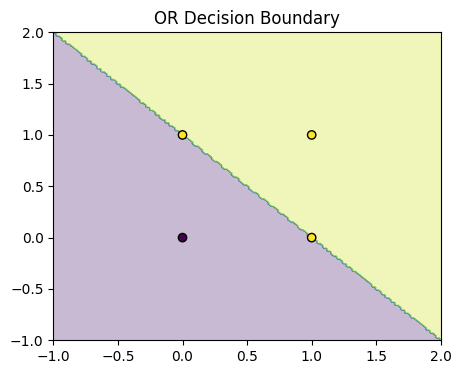

Random Dataset Accuracy: 1.0


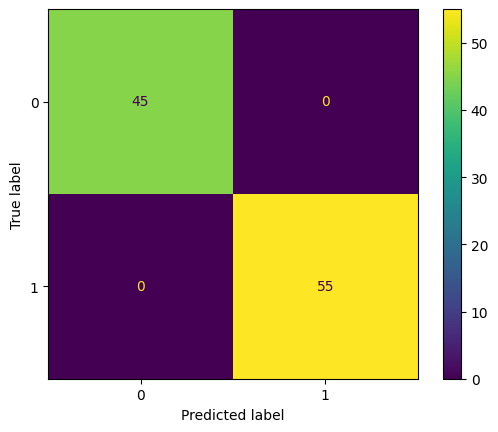

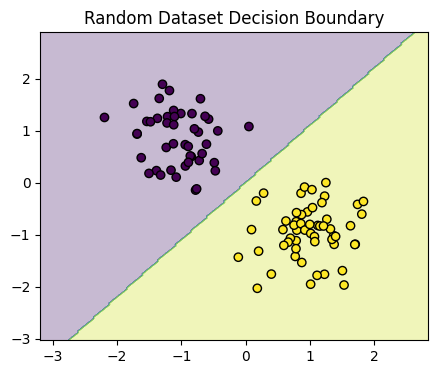

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class Perceptron:
    def __init__(self,input_size,learning_rate=0.1):
        self.lr=learning_rate
        self.weights=np.zeros(input_size)
        self.bias=0
    def activation(self,x): return 1 if x>=0 else 0
    def predict(self,x): return self.activation(np.dot(x,self.weights)+self.bias)
    def predict_batch(self,X): return np.array([self.predict(i) for i in X])
    def train(self,X,y,epochs=20):
        for _ in range(epochs):
            for xi,t in zip(X,y):
                e=t-self.predict(xi)
                self.weights+=self.lr*e*xi
                self.bias+=self.lr*e
    def accuracy(self,X,y):
        return np.mean(self.predict_batch(X)==y)

def plot_boundary(model,X,y,title):
    x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
    y_min,y_max=X[:,1].min()-1,X[:,1].max()+1
    xx,yy=np.meshgrid(np.linspace(x_min,x_max,200),np.linspace(y_min,y_max,200))
    Z=model.predict_batch(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(5,4))
    plt.contourf(xx,yy,Z,alpha=0.3)
    plt.scatter(X[:,0],X[:,1],c=y,edgecolors="k")
    plt.title(title)
    plt.show()

# Task1 AND
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([0,0,0,1])
p=Perceptron(2)
p.train(X,y,20)
print("AND Accuracy:",p.accuracy(X,y))
print("Pred:",p.predict_batch(X))
plot_boundary(p,X,y,"AND Decision Boundary")

# Task1 OR
y=np.array([0,1,1,1])
p=Perceptron(2)
p.train(X,y,20)
print("OR Accuracy:",p.accuracy(X,y))
print("Pred:",p.predict_batch(X))
plot_boundary(p,X,y,"OR Decision Boundary")

# Task2
X,y=make_blobs(n_samples=500,n_features=2,centers=2,cluster_std=2,random_state=42)
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42)
sc=StandardScaler()
Xtr=sc.fit_transform(Xtr); Xte=sc.transform(Xte)
p=Perceptron(2)
p.train(Xtr,ytr,100)
pred=p.predict_batch(Xte)
print("Random Dataset Accuracy:",p.accuracy(Xte,yte))
ConfusionMatrixDisplay(confusion_matrix(yte,pred)).plot()
plt.show()
plot_boundary(p,Xte,yte,"Random Dataset Decision Boundary")
